# Sint Maarten Mobility Scenario Lab

**Experimental research sandbox — not part of the production Streamlit application.**

This notebook turns the current mobility model into a reproducible research and communication workflow. It checks input integrity before analysis, reproduces one pinned baseline cohort, builds full-network corridor measures, and creates presentation-ready figures with explicit model caveats.

> Modeled results using synthetic demand — not observed traffic counts. Capacities and free-flow speeds are screening assumptions, and junction or signal delay is not calibrated.

The notebook reads reusable functions from `src/sxm_mobility/`. It writes only to `notebooks/outputs/01_sxm_mobility_scenario_lab/`.

## 1. Safe setup and project imports

The setup discovers the repository root without a machine-specific path, disables bytecode writes, snapshots protected production files, and establishes an output-only sandbox.

The project environment contains the analytical libraries but does not declare Jupyter or `ipykernel`. A temporary local launch that leaves project dependency files unchanged is: `uv run --with jupyterlab --with ipykernel jupyter lab`.

In [1]:
from __future__ import annotations

import ast
import hashlib
import importlib.metadata as metadata
import json
import math
import os
import platform
import re
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path
from textwrap import fill
from typing import Any, Iterable

sys.dont_write_bytecode = True

def find_project_root(start: Path) -> Path:
    override = os.environ.get('SXM_PROJECT_ROOT')
    candidates = [Path(override).expanduser()] if override else []
    candidates.extend([start, *start.parents])
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'sxm_mobility').is_dir():
            return candidate
    raise RuntimeError('Repository root not found. Start Jupyter inside the repository or set SXM_PROJECT_ROOT.')

PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

OUTPUT_DIR = (PROJECT_ROOT / 'notebooks' / 'outputs' / '01_sxm_mobility_scenario_lab').resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GENERATED_OUTPUTS: list[Path] = []

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

PROTECTED_TARGETS = {
    'streamlit': [PROJECT_ROOT / 'scripts', PROJECT_ROOT / '.streamlit'],
    'production_modules': [PROJECT_ROOT / 'src' / 'sxm_mobility'],
    'base_data': [PROJECT_ROOT / 'data' / 'processed' / 'base'],
    'run_artifacts': [PROJECT_ROOT / 'data' / 'processed' / 'runs'],
    'tests_and_project': [
        PROJECT_ROOT / 'tests',
        PROJECT_ROOT / 'pyproject.toml',
        PROJECT_ROOT / 'uv.lock',
        PROJECT_ROOT / 'notebooks' / 'Network Science - SXM Mobility.ipynb',
    ],
}

def protected_files() -> Iterable[tuple[str, Path]]:
    for group, targets in PROTECTED_TARGETS.items():
        for target in targets:
            if target.is_file():
                yield group, target
            elif target.is_dir():
                for path in sorted(p for p in target.rglob('*') if p.is_file()):
                    yield group, path

def protected_snapshot() -> dict[str, dict[str, str]]:
    snapshot: dict[str, dict[str, str]] = {group: {} for group in PROTECTED_TARGETS}
    for group, path in protected_files():
        snapshot[group][str(path.relative_to(PROJECT_ROOT))] = sha256_file(path)
    return snapshot

PROTECTED_BEFORE = protected_snapshot()

import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from PIL import Image
from shapely import wkt
from shapely.geometry import LineString, MultiLineString

from sxm_mobility.assignment.metrics import total_delay, total_system_travel_time
from sxm_mobility.assignment.msa import msa_traffic_assignment
from sxm_mobility.config import settings
from sxm_mobility.demand.od_generation import load_od_parquet, scale_od
from sxm_mobility.io.osm_ingest import load_gpickle
from sxm_mobility.scenarios.catalog import ConnectorSpec, apply_connector, haversine_m

def output_path(name: str) -> Path:
    path = (OUTPUT_DIR / name).resolve()
    if not path.is_relative_to(OUTPUT_DIR):
        raise ValueError(f'Output escaped notebook sandbox: {path}')
    return path

def save_dataframe(frame: pd.DataFrame, name: str) -> Path:
    path = output_path(name)
    frame.to_csv(path, index=False)
    GENERATED_OUTPUTS.append(path)
    return path

def save_json(payload: dict[str, Any], name: str) -> Path:
    path = output_path(name)
    path.write_text(json.dumps(payload, indent=2, default=str), encoding='utf-8')
    GENERATED_OUTPUTS.append(path)
    return path

packages = ['networkx', 'numpy', 'pandas', 'matplotlib', 'shapely', 'osmnx', 'geopandas', 'pyarrow']
version_rows = []
for package in packages:
    try:
        version_rows.append({'component': package, 'version': metadata.version(package)})
    except metadata.PackageNotFoundError:
        version_rows.append({'component': package, 'version': 'not installed'})
version_rows.insert(0, {'component': 'python', 'version': platform.python_version()})
display(pd.DataFrame(version_rows))
print(f'Project root: {PROJECT_ROOT}')
print(f'Isolated outputs: {OUTPUT_DIR}')

,component,version
0,python,3.13.5
1,networkx,3.6.1
2,numpy,2.4.1
3,pandas,2.3.3
4,matplotlib,3.11.0
5,shapely,2.1.2
6,osmnx,2.0.7
7,geopandas,1.1.2
8,pyarrow,22.0.0


Project root: /home/mzero/main/repo/fio_projects/caribbean_automated_systems/fio_caribbean_mobility_graph/mobility_graph_lab
Isolated outputs: /home/mzero/main/repo/fio_projects/caribbean_automated_systems/fio_caribbean_mobility_graph/mobility_graph_lab/notebooks/outputs/01_sxm_mobility_scenario_lab


## 2. Experiment controls

Change `FIGURE_MODE` to `analysis`, `linkedin`, or `presentation` without changing the analytical calculations. Scenario, sensitivity, and centrality sections are opt-in because each can add meaningful runtime.

The baseline is deliberately pinned to the July 2026 GraphML/Parquet/OD cohort identified in the technical audit. The current gpickle is checked but never mixed into that cohort.

In [2]:
FIGURE_MODE = 'analysis'  # analysis | linkedin | presentation
RUN_SCENARIOS = False
RUN_SENSITIVITY = False
RUN_CENTRALITY = False
PINNED_BASELINE_RUN = 'baseline__20260718_0143'
ALLOW_PINNED_GRAPHML_COHORT = True

DEMAND_FACTORS = (0.90, 1.10)
CAPACITY_CHANGE_PCT = 25.0
CONNECTOR_ENDPOINTS: tuple[int, int] | None = None
CONNECTOR_ROUTE_FACTOR = 1.25
CONNECTOR_SPEED_KPH = 40.0
CONNECTOR_LANES = 1.0
CENTRALITY_SAMPLE_N = 200

FIGURE_SPECS = {
    'analysis': {'pixels': (1800, 1200), 'size': (12.0, 8.0), 'dpi': 150, 'top_n': 12},
    'linkedin': {'pixels': (1080, 1350), 'size': (10.8, 13.5), 'dpi': 100, 'top_n': 10},
    'presentation': {'pixels': (1920, 1080), 'size': (12.8, 7.2), 'dpi': 150, 'top_n': 8},
}
if FIGURE_MODE not in FIGURE_SPECS:
    raise ValueError(f'Unknown FIGURE_MODE: {FIGURE_MODE}')

PALETTE = {
    'navy': '#11132a',
    'indigo': '#3e41ee',
    'violet': '#6d28d9',
    'red': '#d64055',
    'ink': '#20233a',
    'muted': '#666b82',
    'road': '#a9adbd',
    'grid': '#dde0eb',
    'paper': '#f7f8fc',
    'white': '#ffffff',
}
DISCLAIMER = (
    'Modeled results using synthetic demand — not observed traffic counts. '
    'Uncalibrated screening model; assumed capacities and free-flow speeds. '
    'Road network © OpenStreetMap contributors.'
)

ASSIGNMENT_CONFIG = {
    'msa_iterations': int(settings.msa_iters),
    'bpr_alpha': float(settings.bpr_alpha),
    'bpr_beta': float(settings.bpr_beta),
}
display(pd.DataFrame([
    {'setting': 'Figure mode', 'value': FIGURE_MODE},
    {'setting': 'Pinned baseline', 'value': PINNED_BASELINE_RUN},
    {'setting': 'MSA iterations', 'value': ASSIGNMENT_CONFIG['msa_iterations']},
    {'setting': 'BPR alpha / beta', 'value': f"{ASSIGNMENT_CONFIG['bpr_alpha']} / {ASSIGNMENT_CONFIG['bpr_beta']}"},
    {'setting': 'Scenario suite', 'value': 'enabled' if RUN_SCENARIOS else 'opt-in'},
    {'setting': 'Sensitivity checks', 'value': 'enabled' if RUN_SENSITIVITY else 'opt-in'},
]))

,setting,value
0,Figure mode,analysis
1,Pinned baseline,baseline__20260718_0143
2,MSA iterations,30
3,BPR alpha / beta,0.15 / 4.0
4,Scenario suite,opt-in
5,Sensitivity checks,opt-in


## 3. Mandatory integrity gate

This gate distinguishes two facts that must not be blurred:

1. The complete production base-artifact bundle is currently mixed: the gpickle does not match the GraphML and tables.
2. A pinned GraphML + Parquet + OD cohort is internally coherent and can be reproduced for controlled research.

The notebook proceeds only with the second cohort. It stops if node IDs, edge keys, OD endpoints, or required assignment attributes do not align.

In [3]:
BASE_DIR = PROJECT_ROOT / 'data' / 'processed' / 'base'
RUN_DIR = PROJECT_ROOT / 'data' / 'processed' / 'runs' / PINNED_BASELINE_RUN
GRAPHML_PATH = BASE_DIR / 'graph.graphml'
GPICKLE_PATH = BASE_DIR / 'graph.gpickle'
NODES_PATH = BASE_DIR / 'nodes.parquet'
EDGES_PATH = BASE_DIR / 'edges.parquet'
OD_PATH = RUN_DIR / 'od.parquet'
SAVED_KPI_PATH = RUN_DIR / 'results_baseline.parquet'

required_paths = [GRAPHML_PATH, GPICKLE_PATH, NODES_PATH, EDGES_PATH, OD_PATH, SAVED_KPI_PATH]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f'Missing pinned cohort inputs: {missing_paths}')

EXPECTED_COHORT_HASHES = {
    GRAPHML_PATH: '2a27930fceeb20a884bafb87ac753feac36811242d1a7b908b1104c5e6b7468a',
    NODES_PATH: 'e1fa83e503d0453cdcc8ff593922f8e81b328a082c11effde500777d5a1d9b61',
    EDGES_PATH: '0ab6ff7eeb1eff684581105b2196c8ed43552b3540d069bd8bb08a8f425f64ad',
    OD_PATH: 'f12afd36e78b7d42e64e863e56372ff44bf8ccc6c7bf84eb93ce07effb1150a8',
    SAVED_KPI_PATH: 'de556aeaf383c44fed2b1d747312d19903d352b959a82a79072b1d1ce36d5f7d',
}
actual_cohort_hashes = {path: sha256_file(path) for path in EXPECTED_COHORT_HASHES}
hash_mismatches = {
    str(path.relative_to(PROJECT_ROOT)): {'expected': expected, 'actual': actual_cohort_hashes[path]}
    for path, expected in EXPECTED_COHORT_HASHES.items()
    if actual_cohort_hashes[path] != expected
}
if hash_mismatches:
    raise RuntimeError('Pinned cohort artifacts changed; re-audit before continuing:\n' + json.dumps(hash_mismatches, indent=2))

GRAPHML_GRAPH = nx.read_graphml(
    GRAPHML_PATH, node_type=int, edge_key_type=int, force_multigraph=True
)
if not isinstance(GRAPHML_GRAPH, nx.MultiDiGraph):
    GRAPHML_GRAPH = nx.MultiDiGraph(GRAPHML_GRAPH)
GPICKLE_GRAPH = load_gpickle(GPICKLE_PATH)
NODES_TABLE = pd.read_parquet(NODES_PATH)
EDGES_TABLE = pd.read_parquet(EDGES_PATH)
PINNED_OD = load_od_parquet(OD_PATH)
SAVED_KPI = pd.read_parquet(SAVED_KPI_PATH).iloc[0]

node_column = 'node_id' if 'node_id' in NODES_TABLE.columns else 'osmid'
table_nodes = set(pd.to_numeric(NODES_TABLE[node_column], errors='coerce').dropna().astype(int))
table_edges = {
    (int(u), int(v), int(k))
    for u, v, k in EDGES_TABLE[['u', 'v', 'key']].dropna().itertuples(index=False, name=None)
}
graphml_nodes = {int(node) for node in GRAPHML_GRAPH.nodes}
graphml_edges = {(int(u), int(v), int(k)) for u, v, k in GRAPHML_GRAPH.edges(keys=True)}
gpickle_nodes = {int(node) for node in GPICKLE_GRAPH.nodes}
gpickle_edges = {(int(u), int(v), int(k)) for u, v, k in GPICKLE_GRAPH.edges(keys=True)}

od_invalid = [
    (int(o), int(d), float(q))
    for o, d, q in PINNED_OD
    if o not in GRAPHML_GRAPH or d not in GRAPHML_GRAPH or not np.isfinite(q) or q < 0
]
numeric_edges_valid = all(
    np.isfinite(float(data.get('t0', np.nan)))
    and float(data.get('t0', 0.0)) > 0
    and np.isfinite(float(data.get('capacity', np.nan)))
    and float(data.get('capacity', 0.0)) > 0
    for _, _, _, data in GRAPHML_GRAPH.edges(keys=True, data=True)
)
coordinates_valid = all(
    np.isfinite(float(data.get('x', np.nan))) and np.isfinite(float(data.get('y', np.nan)))
    for _, data in GRAPHML_GRAPH.nodes(data=True)
)
strongly_connected = nx.is_strongly_connected(GRAPHML_GRAPH)

checks = [
    {'scope': 'analysis cohort', 'check': 'Pinned artifact hashes match audited cohort', 'passed': len(hash_mismatches) == 0, 'detail': f'{len(EXPECTED_COHORT_HASHES)} files checked'},
    {'scope': 'analysis cohort', 'check': 'GraphML nodes match node table', 'passed': graphml_nodes == table_nodes, 'detail': f'{len(graphml_nodes):,} vs {len(table_nodes):,}'},
    {'scope': 'analysis cohort', 'check': 'GraphML edges match edge table', 'passed': graphml_edges == table_edges, 'detail': f'{len(graphml_edges):,} vs {len(table_edges):,}'},
    {'scope': 'analysis cohort', 'check': 'Pinned OD endpoints and demand valid', 'passed': len(od_invalid) == 0, 'detail': f'{len(PINNED_OD) - len(od_invalid):,}/{len(PINNED_OD):,} valid'},
    {'scope': 'analysis cohort', 'check': 'Positive finite t0 and capacity', 'passed': numeric_edges_valid, 'detail': f'{GRAPHML_GRAPH.number_of_edges():,} edges checked'},
    {'scope': 'analysis cohort', 'check': 'Node coordinates available', 'passed': coordinates_valid, 'detail': f'{GRAPHML_GRAPH.number_of_nodes():,} nodes checked'},
    {'scope': 'analysis cohort', 'check': 'Directed graph strongly connected', 'passed': strongly_connected, 'detail': 'all OD pairs have a network path' if strongly_connected else 'disconnected components detected'},
    {'scope': 'production bundle', 'check': 'gpickle matches pinned GraphML nodes', 'passed': gpickle_nodes == graphml_nodes, 'detail': f'{len(gpickle_nodes):,} vs {len(graphml_nodes):,}'},
    {'scope': 'production bundle', 'check': 'gpickle matches pinned GraphML edges', 'passed': gpickle_edges == graphml_edges, 'detail': f'{len(gpickle_edges):,} vs {len(graphml_edges):,}'},
]
INTEGRITY_REPORT = pd.DataFrame(checks)
INTEGRITY_REPORT['status'] = np.where(INTEGRITY_REPORT['passed'], 'PASS', 'FAIL')
display(INTEGRITY_REPORT[['scope', 'check', 'status', 'detail']])
save_dataframe(INTEGRITY_REPORT, 'model_integrity_report.csv')

COHORT_GATE_PASS = bool(INTEGRITY_REPORT.query("scope == 'analysis cohort'")['passed'].all())
PRODUCTION_BUNDLE_MATCH = bool(INTEGRITY_REPORT.query("scope == 'production bundle'")['passed'].all())
if not ALLOW_PINNED_GRAPHML_COHORT and not PRODUCTION_BUNDLE_MATCH:
    raise RuntimeError('Production base artifacts do not match and pinned-cohort recovery is disabled.')
if not COHORT_GATE_PASS:
    raise RuntimeError('Pinned analysis cohort failed the integrity gate; stop before assignment or publication.')

if not PRODUCTION_BUNDLE_MATCH:
    display(Markdown(
        '**Production artifact warning:** the gpickle is a different graph snapshot. '
        'This notebook will use only the pinned GraphML/Parquet/OD cohort and will not mix artifacts.'
    ))

BASE_GRAPH = nx.freeze(GRAPHML_GRAPH)
BASE_GRAPH_FILE_HASH = sha256_file(GRAPHML_PATH)
OD_FILE_HASH = sha256_file(OD_PATH)
print(f'Pinned analysis graph: {BASE_GRAPH.number_of_nodes():,} nodes / {BASE_GRAPH.number_of_edges():,} directed edges')
print(f'Pinned modeled demand: {sum(q for _, _, q in PINNED_OD):,.0f} vehicle-trips in the modeled hour')

,scope,check,status,detail
0,analysis cohort,Pinned artifact hashes match audited cohort,PASS,5 files checked
1,analysis cohort,GraphML nodes match node table,PASS,"1,965 vs 1,965"
2,analysis cohort,GraphML edges match edge table,PASS,"4,423 vs 4,423"
3,analysis cohort,Pinned OD endpoints and demand valid,PASS,250/250 valid
4,analysis cohort,Positive finite t0 and capacity,PASS,"4,423 edges checked"
5,analysis cohort,Node coordinates available,PASS,"1,965 nodes checked"
6,analysis cohort,Directed graph strongly connected,PASS,all OD pairs have a network path
7,production bundle,gpickle matches pinned GraphML nodes,FAIL,"1,961 vs 1,965"
8,production bundle,gpickle matches pinned GraphML edges,FAIL,"4,419 vs 4,423"


**Production artifact warning:** the gpickle is a different graph snapshot. This notebook will use only the pinned GraphML/Parquet/OD cohort and will not mix artifacts.

Pinned analysis graph: 1,965 nodes / 4,423 directed edges
Pinned modeled demand: 25,000 vehicle-trips in the modeled hour


## 4. Notebook-local analytical layer

The functions below remain notebook-local by design. They parse OSM labels, create fallback geometry, assign every directed edge to exactly one corridor or residual group, and prepare output tables. Nothing is promoted into production code in this block.

In [4]:
CORRIDOR_ALIASES = {
    'suckergardenroad': 'Sucker Garden Road',
    'gaarnellboulevard': 'G. A. Arnell Boulevard',
    'ajcbrouwersweg': 'A.J.C. Brouwersweg',
}

def osm_values(value: Any) -> list[str]:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, (list, tuple, set)):
        return [str(item).strip() for item in value if str(item).strip()]
    text = str(value).strip()
    if not text or text.lower() in {'nan', 'none', 'null'}:
        return []
    for parser in (json.loads, ast.literal_eval):
        try:
            parsed = parser(text)
        except Exception:
            continue
        if isinstance(parsed, (list, tuple, set)):
            return [str(item).strip() for item in parsed if str(item).strip()]
        if isinstance(parsed, str) and parsed.strip():
            return [parsed.strip()]
    return [text]

def canonical_key(text: str) -> str:
    return re.sub(r'[^a-z0-9]+', '', text.casefold())

def corridor_label(edge_data: dict[str, Any]) -> tuple[str, str, bool]:
    names = osm_values(edge_data.get('name'))
    if names:
        normalized_names = []
        for name in names:
            cleaned = re.sub(r'\s+', ' ', name).strip()
            label = CORRIDOR_ALIASES.get(canonical_key(cleaned), cleaned)
            if label not in normalized_names:
                normalized_names.append(label)
        if len(normalized_names) == 1:
            return normalized_names[0], 'Named corridor', len(names) > 1
        return 'Unresolved multi-name edge', 'Residual road group', True
    highway_values = osm_values(edge_data.get('highway'))
    highway = highway_values[0] if highway_values else 'road'
    fallback = re.sub(r'[_-]+', ' ', highway).strip().title()
    return f'Unnamed / {fallback}', 'Residual road group', False

def edge_geometry(graph: nx.MultiDiGraph, u: int, v: int, data: dict[str, Any]):
    geometry = data.get('geometry')
    if isinstance(geometry, (LineString, MultiLineString)):
        return geometry
    if isinstance(geometry, str) and geometry.strip():
        try:
            parsed = wkt.loads(geometry)
            if isinstance(parsed, (LineString, MultiLineString)):
                return parsed
        except Exception:
            pass
    start = graph.nodes[u]
    end = graph.nodes[v]
    return LineString([(float(start['x']), float(start['y'])), (float(end['x']), float(end['y']))])

def graph_state_digest(graph: nx.MultiDiGraph) -> str:
    digest = hashlib.sha256()
    digest.update(f'{graph.number_of_nodes()}|{graph.number_of_edges()}'.encode())
    for u, v, key, data in sorted(graph.edges(keys=True, data=True), key=lambda row: (int(row[0]), int(row[1]), int(row[2]))):
        payload = (
            int(u), int(v), int(key),
            float(data.get('capacity', 0.0)),
            float(data.get('t0', 0.0)),
            float(data.get('time', 0.0)),
            float(data.get('flow', 0.0)),
        )
        digest.update(repr(payload).encode())
    return digest.hexdigest()

def assignment_diagnostics(graph: nx.MultiDiGraph, od: list[tuple[int, int, float]]) -> dict[str, float]:
    tstt = total_system_travel_time(graph)
    shortest_path_cost = sum(
        float(demand) * float(nx.shortest_path_length(graph, origin, destination, weight='time'))
        for origin, destination, demand in od
    ) / 3600.0
    relative_gap = max(0.0, (tstt - shortest_path_cost) / tstt) if tstt > 0 else 0.0
    modeled_balance: dict[int, float] = {}
    expected_balance: dict[int, float] = {}
    for u, v, _, data in graph.edges(keys=True, data=True):
        flow = float(data.get('flow', 0.0))
        modeled_balance[int(u)] = modeled_balance.get(int(u), 0.0) + flow
        modeled_balance[int(v)] = modeled_balance.get(int(v), 0.0) - flow
    for origin, destination, demand in od:
        expected_balance[int(origin)] = expected_balance.get(int(origin), 0.0) + float(demand)
        expected_balance[int(destination)] = expected_balance.get(int(destination), 0.0) - float(demand)
    nodes = set(modeled_balance) | set(expected_balance)
    max_residual = max(
        (abs(modeled_balance.get(node, 0.0) - expected_balance.get(node, 0.0)) for node in nodes),
        default=0.0,
    )
    return {'relative_gap': relative_gap, 'flow_conservation_max_residual_vph': max_residual}

def build_edge_pressure(graph: nx.MultiDiGraph) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for u, v, key, data in graph.edges(keys=True, data=True):
        flow = float(data.get('flow', 0.0))
        capacity = float(data.get('capacity', 0.0))
        time_s = float(data.get('time', 0.0))
        t0_s = float(data.get('t0', time_s))
        corridor, corridor_type, multi_name = corridor_label(data)
        rows.append({
            'u': int(u),
            'v': int(v),
            'key': int(key),
            'corridor': corridor,
            'corridor_type': corridor_type,
            'multi_name_source': bool(multi_name),
            'highway': osm_values(data.get('highway'))[0] if osm_values(data.get('highway')) else 'road',
            'length_m': float(data.get('length', 0.0)),
            'flow_vph': flow,
            'capacity_vph': capacity,
            'v_c': flow / capacity if capacity > 0 else np.nan,
            'freeflow_time_s': t0_s,
            'modeled_time_s': time_s,
            'delay_veh_hours': flow * max(0.0, time_s - t0_s) / 3600.0,
            'geometry': edge_geometry(graph, int(u), int(v), data),
        })
    return pd.DataFrame(rows).sort_values(['delay_veh_hours', 'v_c'], ascending=False).reset_index(drop=True)

def build_corridor_summary(edge_frame: pd.DataFrame, system_delay: float) -> pd.DataFrame:
    summary = (
        edge_frame.groupby(['corridor', 'corridor_type'], as_index=False)
        .agg(
            modeled_delay_veh_hours=('delay_veh_hours', 'sum'),
            directed_segments=('key', 'size'),
            network_length_km=('length_m', lambda values: float(values.sum()) / 1000.0),
            maximum_v_c=('v_c', 'max'),
        )
    )
    summary['modeled_delay_share_pct'] = np.where(
        system_delay > 0, 100.0 * summary['modeled_delay_veh_hours'] / system_delay, 0.0
    )
    return summary.sort_values('modeled_delay_veh_hours', ascending=False).reset_index(drop=True)

BASE_GRAPH_STATE = graph_state_digest(BASE_GRAPH)
print('Notebook-local parsing, geometry, aggregation, and immutability helpers are ready.')

Notebook-local parsing, geometry, aggregation, and immutability helpers are ready.


## 5. Reproduce the pinned baseline

Assignment runs on a copy. The loaded baseline object remains untouched. Recomputed system metrics are compared with the pinned saved KPI before any headline or figure is treated as reproducible.

In [5]:
EXPERIMENT_OD = [(int(o), int(d), float(q)) for o, d, q in PINNED_OD]
MODELED_DEMAND = float(sum(q for _, _, q in EXPERIMENT_OD))

baseline_graph = BASE_GRAPH.copy()
baseline_assigned = msa_traffic_assignment(
    baseline_graph,
    EXPERIMENT_OD,
    iters=ASSIGNMENT_CONFIG['msa_iterations'],
    alpha=ASSIGNMENT_CONFIG['bpr_alpha'],
    beta=ASSIGNMENT_CONFIG['bpr_beta'],
)
if graph_state_digest(BASE_GRAPH) != BASE_GRAPH_STATE:
    raise RuntimeError('Loaded baseline graph was mutated. Stop: notebook isolation failed.')

BASELINE_TSTT = total_system_travel_time(baseline_assigned)
BASELINE_DELAY = total_delay(baseline_assigned)
BASELINE_AVG_TRAVEL_MIN = 60.0 * BASELINE_TSTT / MODELED_DEMAND
BASELINE_AVG_DELAY_MIN = 60.0 * BASELINE_DELAY / MODELED_DEMAND
BASELINE_DIAGNOSTICS = assignment_diagnostics(baseline_assigned, EXPERIMENT_OD)

reproduction_rows = [
    {'metric': 'TSTT (vehicle-hours)', 'saved': float(SAVED_KPI['tstt']), 'recomputed': BASELINE_TSTT},
    {'metric': 'Modeled delay (vehicle-hours)', 'saved': float(SAVED_KPI['delay']), 'recomputed': BASELINE_DELAY},
    {'metric': 'Average trip time (min/vehicle)', 'saved': float(SAVED_KPI['avg_travel_time_min']), 'recomputed': BASELINE_AVG_TRAVEL_MIN},
    {'metric': 'Average delay (min/vehicle)', 'saved': float(SAVED_KPI['avg_delay_min']), 'recomputed': BASELINE_AVG_DELAY_MIN},
]
REPRODUCTION_REPORT = pd.DataFrame(reproduction_rows)
REPRODUCTION_REPORT['absolute_difference'] = (REPRODUCTION_REPORT['recomputed'] - REPRODUCTION_REPORT['saved']).abs()
REPRODUCTION_REPORT['passed'] = np.isclose(
    REPRODUCTION_REPORT['saved'], REPRODUCTION_REPORT['recomputed'], rtol=1e-12, atol=1e-9
)
REPRODUCTION_GATE_PASS = bool(REPRODUCTION_REPORT['passed'].all())
display(REPRODUCTION_REPORT)
save_dataframe(REPRODUCTION_REPORT, 'baseline_reproduction_check.csv')
if not REPRODUCTION_GATE_PASS:
    raise RuntimeError('Pinned baseline did not reproduce. Stop before corridor analysis or figure export.')

EDGE_PRESSURE = build_edge_pressure(baseline_assigned)
if not math.isclose(float(EDGE_PRESSURE['delay_veh_hours'].sum()), BASELINE_DELAY, rel_tol=1e-12, abs_tol=1e-9):
    raise RuntimeError('Full-edge delay table does not reconcile to system delay.')

CORRIDOR_PRESSURE = build_corridor_summary(EDGE_PRESSURE, BASELINE_DELAY)
if not math.isclose(float(CORRIDOR_PRESSURE['modeled_delay_share_pct'].sum()), 100.0, rel_tol=1e-10, abs_tol=1e-8):
    raise RuntimeError('Corridor shares do not sum to 100%.')

BASELINE_SUMMARY = pd.DataFrame([{
    'analysis_cohort': PINNED_BASELINE_RUN,
    'modeled_vehicle_trips_in_hour': MODELED_DEMAND,
    'od_pairs': len(EXPERIMENT_OD),
    'graph_nodes': BASE_GRAPH.number_of_nodes(),
    'directed_edges': BASE_GRAPH.number_of_edges(),
    'tstt_veh_hours': BASELINE_TSTT,
    'modeled_delay_veh_hours': BASELINE_DELAY,
    'avg_trip_time_min_per_vehicle': BASELINE_AVG_TRAVEL_MIN,
    'avg_delay_min_per_vehicle': BASELINE_AVG_DELAY_MIN,
    'relative_gap': BASELINE_DIAGNOSTICS['relative_gap'],
    'flow_conservation_max_residual_vph': BASELINE_DIAGNOSTICS['flow_conservation_max_residual_vph'],
    'reproduction_gate': 'PASS',
    'calibration_status': 'Uncalibrated screening model',
}])

edge_export = EDGE_PRESSURE.drop(columns=['geometry']).copy()
edge_export['geometry_wkt'] = EDGE_PRESSURE['geometry'].map(lambda geometry: geometry.wkt)
save_dataframe(BASELINE_SUMMARY, 'baseline_summary.csv')
save_dataframe(edge_export, 'edge_pressure.csv')
save_dataframe(CORRIDOR_PRESSURE, 'corridor_pressure.csv')

PROVENANCE = {
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
    'research_status': 'experimental sandbox',
    'figure_mode': FIGURE_MODE,
    'run_scenarios': RUN_SCENARIOS,
    'run_sensitivity': RUN_SENSITIVITY,
    'run_centrality': RUN_CENTRALITY,
    'analysis_graph': str(GRAPHML_PATH.relative_to(PROJECT_ROOT)),
    'analysis_graph_sha256': BASE_GRAPH_FILE_HASH,
    'od_file': str(OD_PATH.relative_to(PROJECT_ROOT)),
    'od_sha256': OD_FILE_HASH,
    'pinned_baseline_run': PINNED_BASELINE_RUN,
    'assignment': ASSIGNMENT_CONFIG,
    'cohort_integrity_gate': COHORT_GATE_PASS,
    'baseline_reproduction_gate': REPRODUCTION_GATE_PASS,
    'production_bundle_match': PRODUCTION_BUNDLE_MATCH,
    'scientific_disclaimer': DISCLAIMER,
}
save_json(PROVENANCE, 'provenance.json')

2026-08-17 23:37:23.145 | INFO     | sxm_mobility.assignment.msa:msa_traffic_assignment:133 - Assigned OD (endpoints found): 250, Failed OD (missing endpoints): 0


,metric,saved,recomputed,absolute_difference,passed
0,TSTT (vehicle-hours),7589.972211,7589.972211,0.000000e+00,True
1,Modeled delay (vehicle-hours),3864.671581,3864.671581,0.000000e+00,True
2,Average trip time (min/vehicle),18.215933,18.215933,3.552714e-15,True
3,Average delay (min/vehicle),9.275212,9.275212,0.000000e+00,True


PosixPath('/home/mzero/main/repo/fio_projects/caribbean_automated_systems/fio_caribbean_mobility_graph/mobility_graph_lab/notebooks/outputs/01_sxm_mobility_scenario_lab/provenance.json')

## 6. Baseline decision readout

The baseline view uses all 4,423 directed edges, not the saved top-50 shortlist. Every edge is assigned once to a named corridor or a clearly labeled residual road group.

In [6]:
named_corridors = CORRIDOR_PRESSURE.query("corridor_type == 'Named corridor'").copy()
top_three_share = float(named_corridors.head(3)['modeled_delay_share_pct'].sum())
residual_share = float(CORRIDOR_PRESSURE.query("corridor_type == 'Residual road group'")['modeled_delay_share_pct'].sum())
multi_name_share = float(
    100.0 * EDGE_PRESSURE.loc[EDGE_PRESSURE['multi_name_source'], 'delay_veh_hours'].sum() / BASELINE_DELAY
)
leader = named_corridors.iloc[0]

display(Markdown(f'''
### Where the model concentrates pressure

- The pinned case represents **{MODELED_DEMAND:,.0f} modeled vehicle trips in the hour**.
- Average modeled trip time is **{BASELINE_AVG_TRAVEL_MIN:.1f} minutes per vehicle**, including **{BASELINE_AVG_DELAY_MIN:.1f} minutes of modeled congestion delay**.
- **{leader['corridor']}** accounts for **{leader['modeled_delay_share_pct']:.1f}%** of total modeled network delay.
- The top three named corridors account for **{top_three_share:.1f}%**.
- Residual unnamed and review groups account for **{residual_share:.1f}%**; unresolved multi-name OSM records account for **{multi_name_share:.1f}%** and are not guessed into a corridor.
- The 30-iteration assignment has a diagnostic relative gap of **{100.0 * BASELINE_DIAGNOSTICS['relative_gap']:.2f}%**; this is not a calibrated equilibrium claim.

These are screening results, not observed traffic conditions or an engineering forecast.
'''))
display(named_corridors.head(12)[[
    'corridor', 'modeled_delay_share_pct', 'modeled_delay_veh_hours',
    'directed_segments', 'maximum_v_c'
]].style.format({
    'modeled_delay_share_pct': '{:.1f}%',
    'modeled_delay_veh_hours': '{:.1f}',
    'maximum_v_c': '{:.2f}',
}))


### Where the model concentrates pressure

- The pinned case represents **25,000 modeled vehicle trips in the hour**.
- Average modeled trip time is **18.2 minutes per vehicle**, including **9.3 minutes of modeled congestion delay**.
- **A.J.C. Brouwersweg** accounts for **45.9%** of total modeled network delay.
- The top three named corridors account for **66.3%**.
- Residual unnamed and review groups account for **0.9%**; unresolved multi-name OSM records account for **0.4%** and are not guessed into a corridor.
- The 30-iteration assignment has a diagnostic relative gap of **0.83%**; this is not a calibrated equilibrium claim.

These are screening results, not observed traffic conditions or an engineering forecast.


,corridor,modeled_delay_share_pct,modeled_delay_veh_hours,directed_segments,maximum_v_c
0,A.J.C. Brouwersweg,45.9%,1772.0,35,4.06
1,G. A. Arnell Boulevard,10.9%,422.6,6,2.61
2,Indigo Bay Roundabout,9.5%,368.1,8,4.41
3,A.T. Illidge Road,7.1%,275.1,112,2.31
4,Zagersgut Road,3.5%,134.0,16,2.09
5,Union Road,3.1%,120.9,95,1.88
6,Osborne Kruythoff Roundabout,3.0%,114.8,7,3.87
7,Sucker Garden Road,3.0%,114.5,46,1.92
8,Welfare Road,2.3%,89.4,25,2.13
9,Arlet Peters Road,2.2%,86.2,4,2.01


## 7. Presentation figures

The same calculations feed every figure mode. Visual styling changes dimensions and density only; values remain identical. Each exported figure carries the scientific disclaimer.

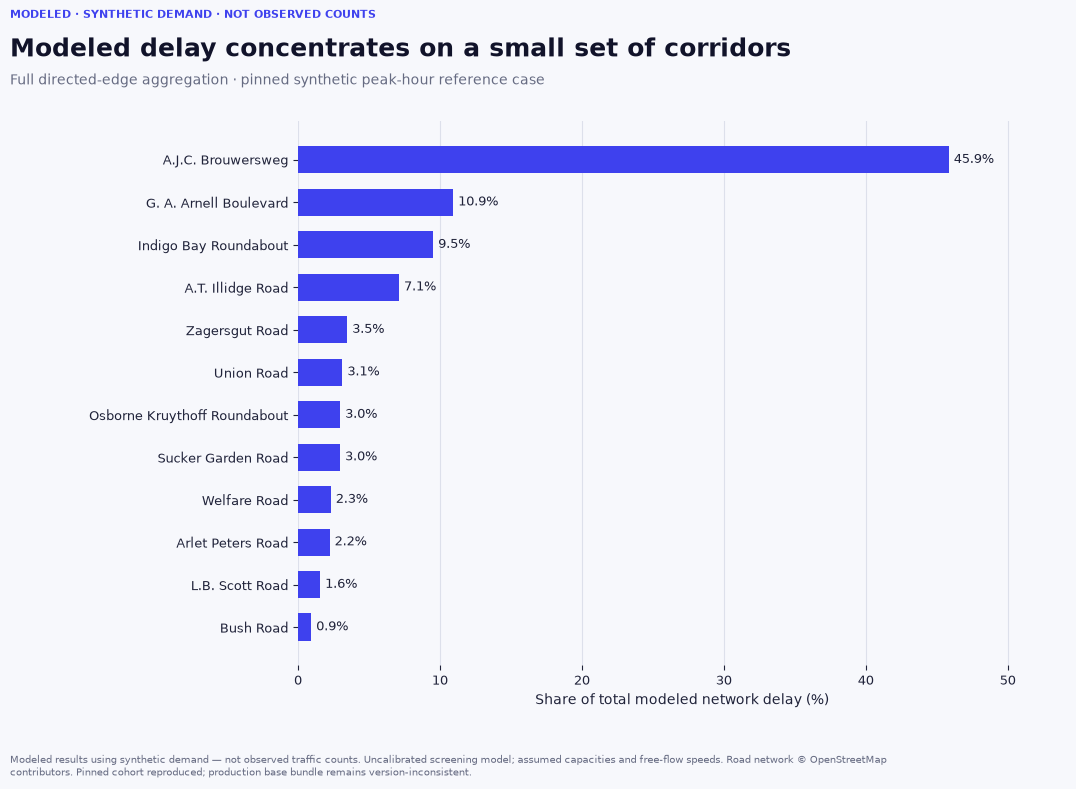

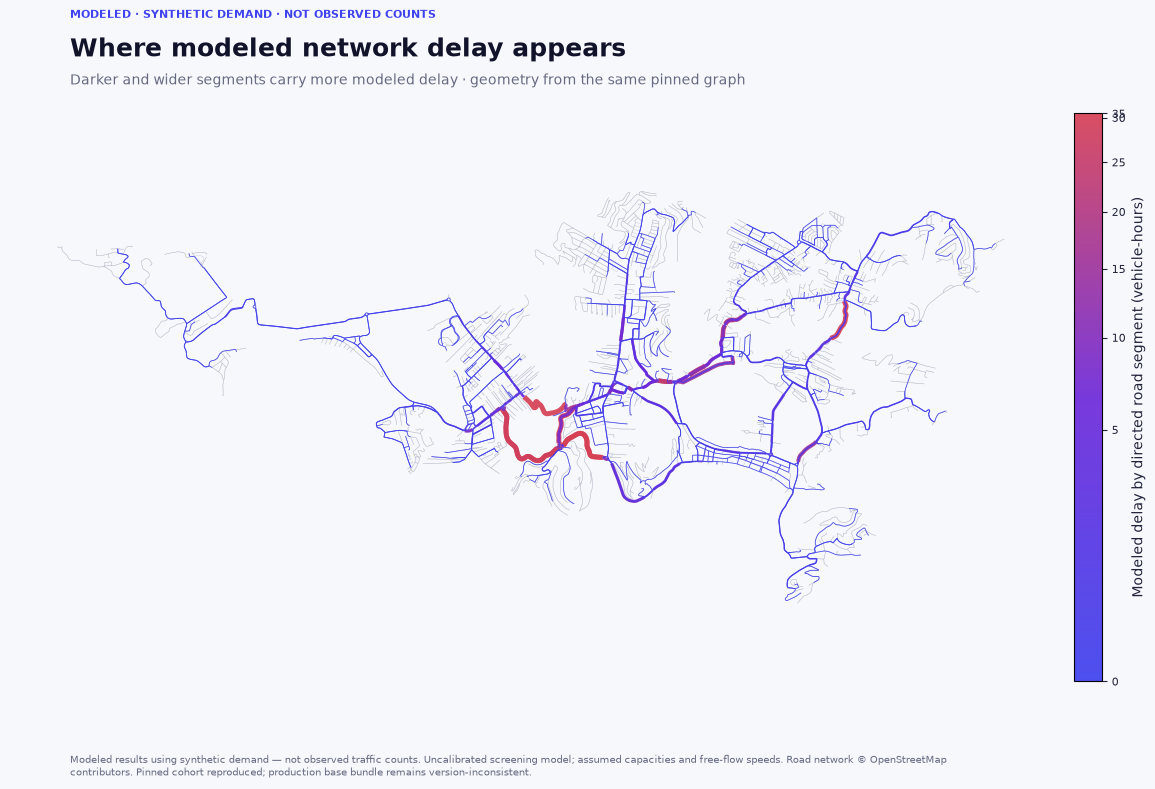

In [7]:
FIGURE_CONFIG = FIGURE_SPECS[FIGURE_MODE]
FIGURE_DISCLAIMER = DISCLAIMER + (
    ' Pinned cohort reproduced; production base bundle remains version-inconsistent.'
    if not PRODUCTION_BUNDLE_MATCH else ''
)

def save_figure(fig: mpl.figure.Figure, stem: str) -> list[Path]:
    paths = []
    for suffix in ('png', 'svg'):
        path = output_path(f'{stem}.{suffix}')
        fig.savefig(
            path,
            dpi=FIGURE_CONFIG['dpi'],
            bbox_inches=None,
            facecolor=fig.get_facecolor(),
        )
        GENERATED_OUTPUTS.append(path)
        paths.append(path)
        if suffix == 'png':
            with Image.open(path) as exported_image:
                if exported_image.size != tuple(FIGURE_CONFIG['pixels']):
                    raise RuntimeError(f'Unexpected PNG dimensions for {path.name}: {exported_image.size}')
    return paths

def add_figure_text(fig: mpl.figure.Figure, title: str, subtitle: str) -> None:
    fig.text(0.07, 0.980, 'MODELED · SYNTHETIC DEMAND · NOT OBSERVED COUNTS', color=PALETTE['indigo'], fontsize=8, fontweight='bold', va='top')
    fig.text(0.07, 0.945, title, color=PALETTE['navy'], fontsize=18, fontweight='bold', va='top')
    fig.text(0.07, 0.900, subtitle, color=PALETTE['muted'], fontsize=10, va='top')
    footer_width = 100 if FIGURE_MODE == 'linkedin' else 175
    fig.text(0.07, 0.018, fill(FIGURE_DISCLAIMER, width=footer_width), color=PALETTE['muted'], fontsize=7.5, va='bottom')

plot_frame = named_corridors.head(int(FIGURE_CONFIG['top_n'])).sort_values('modeled_delay_share_pct')
with plt.rc_context({'font.family': 'DejaVu Sans', 'axes.titleweight': 'bold'}):
    fig, ax = plt.subplots(figsize=FIGURE_CONFIG['size'], facecolor=PALETTE['paper'])
    ax.set_facecolor(PALETTE['paper'])
    bars = ax.barh(
        plot_frame['corridor'], plot_frame['modeled_delay_share_pct'],
        color=PALETTE['indigo'], height=0.64
    )
    for bar, value in zip(bars, plot_frame['modeled_delay_share_pct'], strict=True):
        ax.text(value + 0.35, bar.get_y() + bar.get_height() / 2, f'{value:.1f}%',
                va='center', color=PALETTE['ink'], fontsize=9)
    ax.set_xlabel('Share of total modeled network delay (%)', color=PALETTE['ink'])
    ax.set_xlim(0, max(5.0, float(plot_frame['modeled_delay_share_pct'].max()) * 1.18))
    ax.xaxis.grid(True, color=PALETTE['grid'], linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors=PALETTE['ink'], labelsize=9)
    add_figure_text(
        fig,
        'Modeled delay concentrates on a small set of corridors',
        'Full directed-edge aggregation · pinned synthetic peak-hour reference case',
    )
    fig.subplots_adjust(left=0.31, right=0.95, top=0.84, bottom=0.16)
    save_figure(fig, 'corridor_pressure_ranking')
    plt.show()

def geometry_segments(geometry) -> list[np.ndarray]:
    if isinstance(geometry, LineString):
        return [np.asarray(geometry.coords)]
    if isinstance(geometry, MultiLineString):
        return [np.asarray(part.coords) for part in geometry.geoms]
    return []

base_segments: list[np.ndarray] = []
pressure_segments: list[np.ndarray] = []
pressure_values: list[float] = []
for row in EDGE_PRESSURE.itertuples(index=False):
    segments = geometry_segments(row.geometry)
    base_segments.extend(segments)
    if row.delay_veh_hours > 0:
        pressure_segments.extend(segments)
        pressure_values.extend([float(row.delay_veh_hours)] * len(segments))

pressure_array = np.asarray(pressure_values, dtype=float)
upper = float(np.quantile(pressure_array, 0.99)) if len(pressure_array) else 1.0
upper = max(upper, float(pressure_array.max()) * 0.05 if len(pressure_array) else 1.0, 1e-9)
norm = PowerNorm(gamma=0.45, vmin=0.0, vmax=upper, clip=True)
cmap = LinearSegmentedColormap.from_list('mobility_pressure', [PALETTE['indigo'], PALETTE['violet'], PALETTE['red']])
line_widths = 0.55 + 3.0 * np.power(np.clip(pressure_array / upper, 0.0, 1.0), 0.45)

with plt.rc_context({'font.family': 'DejaVu Sans'}):
    fig, ax = plt.subplots(figsize=FIGURE_CONFIG['size'], facecolor=PALETTE['paper'])
    ax.set_facecolor(PALETTE['paper'])
    ax.add_collection(LineCollection(base_segments, colors=PALETTE['road'], linewidths=0.35, alpha=0.55, zorder=1))
    pressure_collection = LineCollection(
        pressure_segments, cmap=cmap, norm=norm, linewidths=line_widths, alpha=0.92, zorder=2
    )
    pressure_collection.set_array(pressure_array)
    ax.add_collection(pressure_collection)
    ax.autoscale()
    ax.set_aspect('equal', adjustable='datalim')
    ax.axis('off')
    colorbar = fig.colorbar(pressure_collection, ax=ax, fraction=0.026, pad=0.02)
    colorbar.set_label('Modeled delay by directed road segment (vehicle-hours)', color=PALETTE['ink'])
    colorbar.ax.tick_params(colors=PALETTE['ink'], labelsize=8)
    add_figure_text(
        fig,
        'Where modeled network delay appears',
        'Darker and wider segments carry more modeled delay · geometry from the same pinned graph',
    )
    fig.subplots_adjust(left=0.02, right=0.93, top=0.86, bottom=0.13)
    save_figure(fig, 'network_pressure_map')
    plt.show()

## 8. Optional structural-centrality screen

Centrality is a topology measure, not a traffic count. When enabled, this section estimates edge betweenness on a simplified directed graph and labels it separately from modeled flow and delay.

In [8]:
CENTRALITY_COMPLETE = False
if RUN_CENTRALITY:
    simple_graph = nx.DiGraph()
    for u, v, data in BASE_GRAPH.edges(data=True):
        weight = float(data.get('t0', 1.0))
        if not simple_graph.has_edge(u, v) or weight < simple_graph[u][v]['t0']:
            simple_graph.add_edge(u, v, t0=weight)
    sample_n = min(int(CENTRALITY_SAMPLE_N), simple_graph.number_of_nodes())
    centrality = nx.edge_betweenness_centrality(
        simple_graph, k=sample_n, normalized=True, weight='t0', seed=int(settings.od_seed)
    )
    centrality_rows = []
    for (u, v), value in centrality.items():
        candidates = [data for _, data in BASE_GRAPH[u][v].items()]
        label, label_type, _ = corridor_label(min(candidates, key=lambda item: float(item.get('t0', 1.0))))
        centrality_rows.append({
            'u': int(u), 'v': int(v), 'corridor': label, 'corridor_type': label_type,
            'approx_edge_betweenness': float(value),
        })
    CENTRALITY_SCREEN = pd.DataFrame(centrality_rows).sort_values('approx_edge_betweenness', ascending=False)
    save_dataframe(CENTRALITY_SCREEN, 'centrality_screen.csv')
    CENTRALITY_COMPLETE = True
    display(CENTRALITY_SCREEN.head(20))
else:
    print('Centrality screen not run. Set RUN_CENTRALITY = True to enable it.')

Centrality screen not run. Set RUN_CENTRALITY = True to enable it.


## 9. Optional scenario suite

Every scenario begins with `BASE_GRAPH.copy()`. Fixed-demand network changes and demand changes are reported separately because they answer different questions.

- **Network scenarios:** average modeled trip time is primary; delay is secondary; disconnected demand is always reported.
- **Demand scenarios:** per-vehicle experience and total burden are both shown; they are not ranked against infrastructure cases.
- **Connector:** no connector runs until explicit endpoints are supplied. Straight-line distance is expanded by a visible route-factor assumption.

In [9]:
def demand_coverage(graph: nx.MultiDiGraph, od: list[tuple[int, int, float]]) -> dict[str, float]:
    missing = 0.0
    unreachable = 0.0
    for origin, destination, demand in od:
        if origin not in graph or destination not in graph:
            missing += float(demand)
        elif not nx.has_path(graph, origin, destination):
            unreachable += float(demand)
    total = float(sum(q for _, _, q in od))
    return {
        'total_demand_vph': total,
        'missing_endpoint_demand_vph': missing,
        'unreachable_demand_vph': unreachable,
        'served_demand_vph': total - missing - unreachable,
    }

def evaluate_case(name: str, graph: nx.MultiDiGraph, od: list[tuple[int, int, float]], family: str):
    coverage = demand_coverage(graph, od)
    if coverage['missing_endpoint_demand_vph'] > 0 or coverage['unreachable_demand_vph'] > 0:
        return {
            'scenario': name, 'family': family, 'status': 'not run — unserved demand',
            **coverage, 'tstt_veh_hours': np.nan, 'modeled_delay_veh_hours': np.nan,
            'avg_trip_time_min_per_vehicle': np.nan, 'avg_delay_min_per_vehicle': np.nan,
        }, None
    assigned = msa_traffic_assignment(
        graph.copy(), od, iters=ASSIGNMENT_CONFIG['msa_iterations'],
        alpha=ASSIGNMENT_CONFIG['bpr_alpha'], beta=ASSIGNMENT_CONFIG['bpr_beta']
    )
    tstt = total_system_travel_time(assigned)
    delay = total_delay(assigned)
    served = coverage['served_demand_vph']
    return {
        'scenario': name, 'family': family, 'status': 'modeled', **coverage,
        'tstt_veh_hours': tstt, 'modeled_delay_veh_hours': delay,
        'avg_trip_time_min_per_vehicle': 60.0 * tstt / served if served else np.nan,
        'avg_delay_min_per_vehicle': 60.0 * delay / served if served else np.nan,
        **assignment_diagnostics(assigned, od),
    }, assigned

def capacity_case(base_graph: nx.MultiDiGraph, target_corridor: str, pct: float):
    graph = base_graph.copy()
    changed = 0
    for _, _, _, data in graph.edges(keys=True, data=True):
        if corridor_label(data)[0] == target_corridor:
            data['capacity'] = float(data.get('capacity', 0.0)) * (1.0 + pct / 100.0)
            changed += 1
    return graph, changed

def closure_case(base_graph: nx.MultiDiGraph, u: int, v: int):
    graph = base_graph.copy()
    removed = 0
    for start, end in ((u, v), (v, u)):
        if graph.has_edge(start, end):
            for key in list(graph[start][end].keys()):
                graph.remove_edge(start, end, key)
                removed += 1
    return graph, removed

SCENARIOS_COMPLETE = False
if RUN_SCENARIOS:
    baseline_network_row = {
        'scenario': 'Pinned baseline', 'family': 'fixed-demand network', 'status': 'modeled',
        'total_demand_vph': MODELED_DEMAND, 'missing_endpoint_demand_vph': 0.0,
        'unreachable_demand_vph': 0.0, 'served_demand_vph': MODELED_DEMAND,
        'tstt_veh_hours': BASELINE_TSTT, 'modeled_delay_veh_hours': BASELINE_DELAY,
        'avg_trip_time_min_per_vehicle': BASELINE_AVG_TRAVEL_MIN,
        'avg_delay_min_per_vehicle': BASELINE_AVG_DELAY_MIN,
        **BASELINE_DIAGNOSTICS,
        'chart_label': 'Pinned baseline',
    }
    network_rows = [baseline_network_row]

    target_corridor = str(named_corridors.iloc[0]['corridor'])
    capacity_graph, changed_edges = capacity_case(BASE_GRAPH, target_corridor, CAPACITY_CHANGE_PCT)
    row, _ = evaluate_case(
        f'{target_corridor}: capacity +{CAPACITY_CHANGE_PCT:.0f}% ({changed_edges} directed edges)',
        capacity_graph, EXPERIMENT_OD, 'fixed-demand network'
    )
    row['chart_label'] = f'{target_corridor}\nCapacity +{CAPACITY_CHANGE_PCT:.0f}%'
    network_rows.append(row)

    top_edge = EDGE_PRESSURE.iloc[0]
    closed_graph, removed_edges = closure_case(BASE_GRAPH, int(top_edge['u']), int(top_edge['v']))
    row, _ = evaluate_case(
        f'Segment closure near {top_edge["corridor"]} ({removed_edges} directed edges removed)',
        closed_graph, EXPERIMENT_OD, 'fixed-demand network'
    )
    row['chart_label'] = f'{top_edge["corridor"]}\nSegment closure'
    network_rows.append(row)

    if CONNECTOR_ENDPOINTS is not None:
        node_a, node_b = map(int, CONNECTOR_ENDPOINTS)
        if node_a not in BASE_GRAPH or node_b not in BASE_GRAPH:
            raise ValueError('Connector endpoints must exist in the pinned analysis graph.')
        if node_a == node_b or BASE_GRAPH.has_edge(node_a, node_b) or BASE_GRAPH.has_edge(node_b, node_a):
            warnings.warn('Connector skipped: endpoints are identical or already directly connected.')
        else:
            a_data, b_data = BASE_GRAPH.nodes[node_a], BASE_GRAPH.nodes[node_b]
            straight_m = haversine_m(float(a_data['x']), float(a_data['y']), float(b_data['x']), float(b_data['y']))
            connector = ConnectorSpec(
                a=node_a, b=node_b, length_m=straight_m * CONNECTOR_ROUTE_FACTOR,
                speed_kph=CONNECTOR_SPEED_KPH, lanes=CONNECTOR_LANES,
                name='Notebook hypothetical connector',
            )
            connector_graph = BASE_GRAPH.copy()
            apply_connector(connector_graph, connector, two_way=True)
            row, _ = evaluate_case(
                f'Hypothetical connector ({connector.length_m:.0f} m assumed)',
                connector_graph, EXPERIMENT_OD, 'fixed-demand network'
            )
            row['chart_label'] = 'Hypothetical connector'
            network_rows.append(row)

    NETWORK_SCENARIOS = pd.DataFrame(network_rows)
    NETWORK_SCENARIOS['change_in_avg_trip_time_pct'] = 100.0 * (
        NETWORK_SCENARIOS['avg_trip_time_min_per_vehicle'] / BASELINE_AVG_TRAVEL_MIN - 1.0
    )
    NETWORK_SCENARIOS['change_in_avg_delay_pct'] = 100.0 * (
        NETWORK_SCENARIOS['avg_delay_min_per_vehicle'] / BASELINE_AVG_DELAY_MIN - 1.0
    )
    save_dataframe(NETWORK_SCENARIOS, 'network_scenario_comparison.csv')

    demand_rows = []
    for factor in sorted({1.0, *DEMAND_FACTORS}):
        if math.isclose(factor, 1.0):
            row = dict(baseline_network_row)
            row['scenario'] = 'Reference demand'
            row['family'] = 'demand sensitivity'
        else:
            change = (factor - 1.0) * 100.0
            label = f'Demand {change:+.0f}%'
            row, _ = evaluate_case(label, BASE_GRAPH, scale_od(EXPERIMENT_OD, factor), 'demand sensitivity')
        row['demand_change_pct'] = (factor - 1.0) * 100.0
        demand_rows.append(row)
    DEMAND_SCENARIOS = pd.DataFrame(demand_rows).sort_values('demand_change_pct')
    save_dataframe(DEMAND_SCENARIOS, 'demand_sensitivity.csv')

    display(Markdown('### Fixed-demand network cases — average trip time is the primary comparison'))
    display(NETWORK_SCENARIOS)
    display(Markdown('### Demand sensitivity — do not rank against infrastructure cases'))
    display(DEMAND_SCENARIOS)

    with plt.rc_context({'font.family': 'DejaVu Sans'}):
        fig, axes = plt.subplots(1, 2, figsize=FIGURE_CONFIG['size'], facecolor=PALETTE['paper'])
        network_plot = NETWORK_SCENARIOS.dropna(subset=['avg_trip_time_min_per_vehicle'])
        axes[0].barh(network_plot['chart_label'], network_plot['avg_trip_time_min_per_vehicle'], color=PALETTE['indigo'])
        axes[0].set_xlabel('Average modeled trip time (min/vehicle)')
        axes[0].set_title('Fixed-demand network cases', loc='left', color=PALETTE['navy'])
        axes[0].invert_yaxis()
        axes[1].plot(DEMAND_SCENARIOS['demand_change_pct'], DEMAND_SCENARIOS['avg_trip_time_min_per_vehicle'],
                     marker='o', color=PALETTE['indigo'], label='Average trip time')
        axes[1].plot(DEMAND_SCENARIOS['demand_change_pct'], DEMAND_SCENARIOS['avg_delay_min_per_vehicle'],
                     marker='s', color=PALETTE['violet'], label='Average congestion delay')
        axes[1].set_xlabel('Change in modeled vehicle trips (%)')
        axes[1].set_ylabel('Minutes per vehicle')
        axes[1].set_title('Demand sensitivity', loc='left', color=PALETTE['navy'])
        axes[1].legend(frameon=False)
        for ax in axes:
            ax.set_facecolor(PALETTE['paper'])
            ax.grid(axis='x', color=PALETTE['grid'], linewidth=0.8)
            ax.set_axisbelow(True)
            for spine in ax.spines.values():
                spine.set_visible(False)
        add_figure_text(
            fig, 'Scenario signals, kept in their proper comparison families',
            'Network changes hold demand fixed; demand cases change the number of modeled trips',
        )
        fig.subplots_adjust(left=0.20, right=0.96, top=0.82, bottom=0.15, wspace=0.34)
        save_figure(fig, 'scenario_comparison')
        plt.show()

    SCENARIOS_COMPLETE = True
    if graph_state_digest(BASE_GRAPH) != BASE_GRAPH_STATE:
        raise RuntimeError('Scenario suite mutated the loaded baseline graph.')
else:
    print('Scenario suite not run. Set RUN_SCENARIOS = True after reviewing the visible assumptions.')

Scenario suite not run. Set RUN_SCENARIOS = True after reviewing the visible assumptions.


## 10. Optional assignment-iteration sensitivity

The production routine uses a fixed iteration count rather than a convergence stopping rule. This screen compares a small set of iteration counts; it is evidence about numerical sensitivity, not proof of equilibrium.

In [10]:
SENSITIVITY_COMPLETE = False
if RUN_SENSITIVITY:
    sensitivity_rows = [{
        'msa_iterations': ASSIGNMENT_CONFIG['msa_iterations'],
        'tstt_veh_hours': BASELINE_TSTT,
        'modeled_delay_veh_hours': BASELINE_DELAY,
        'avg_trip_time_min_per_vehicle': BASELINE_AVG_TRAVEL_MIN,
        'avg_delay_min_per_vehicle': BASELINE_AVG_DELAY_MIN,
        **BASELINE_DIAGNOSTICS,
    }]
    for iterations in (15, 60):
        assigned = msa_traffic_assignment(
            BASE_GRAPH.copy(), EXPERIMENT_OD, iters=iterations,
            alpha=ASSIGNMENT_CONFIG['bpr_alpha'], beta=ASSIGNMENT_CONFIG['bpr_beta']
        )
        tstt = total_system_travel_time(assigned)
        delay = total_delay(assigned)
        sensitivity_rows.append({
            'msa_iterations': iterations,
            'tstt_veh_hours': tstt,
            'modeled_delay_veh_hours': delay,
            'avg_trip_time_min_per_vehicle': 60.0 * tstt / MODELED_DEMAND,
            'avg_delay_min_per_vehicle': 60.0 * delay / MODELED_DEMAND,
            **assignment_diagnostics(assigned, EXPERIMENT_OD),
        })
    ITERATION_SENSITIVITY = pd.DataFrame(sensitivity_rows).sort_values('msa_iterations')
    ITERATION_SENSITIVITY['tstt_change_vs_30_pct'] = 100.0 * (ITERATION_SENSITIVITY['tstt_veh_hours'] / BASELINE_TSTT - 1.0)
    ITERATION_SENSITIVITY['delay_change_vs_30_pct'] = 100.0 * (ITERATION_SENSITIVITY['modeled_delay_veh_hours'] / BASELINE_DELAY - 1.0)
    save_dataframe(ITERATION_SENSITIVITY, 'assignment_iteration_sensitivity.csv')
    display(ITERATION_SENSITIVITY)
    SENSITIVITY_COMPLETE = True
else:
    print('Iteration sensitivity not run. Set RUN_SENSITIVITY = True before using results beyond exploratory communication.')

Iteration sensitivity not run. Set RUN_SENSITIVITY = True before using results beyond exploratory communication.


## 11. Interpretation and limits

Use this notebook to locate modeled pressure, compare controlled assumptions, test visual encodings, and prepare clearly labeled research graphics. Do not use it to claim observed traffic conditions, forecast demand, approve an intervention, or infer engineering feasibility.

Before a result advances beyond research communication, validate traffic counts and travel times, calibrate capacity and congestion response, include junction and turn effects, define canonical corridors, run assignment sensitivity, and reconcile the production base-artifact bundle.

In [11]:
display(Markdown(f'''
### Research handoff

**What is reproducible now**

- The pinned `{PINNED_BASELINE_RUN}` GraphML/Parquet/OD cohort passes its internal integrity checks.
- The baseline reproduces its saved system metrics within numerical tolerance.
- Full-edge delay reconciles to total system delay, and corridor shares sum to 100%.
- Figures and tables are written only to the notebook output sandbox.

**What remains open**

- The production gpickle remains a different network snapshot from the pinned cohort.
- Demand is synthetic; speeds and capacities are largely assumed or imputed.
- The 30-iteration assignment has no convergence stopping criterion.
- Scenario results are screening estimates and do not establish feasibility, cost, safety, or achievable policy uptake.

**Communication status:** suitable for explicitly labeled exploratory research and draft presentation graphics; not a calibrated engineering forecast.
'''))


### Research handoff

**What is reproducible now**

- The pinned `baseline__20260718_0143` GraphML/Parquet/OD cohort passes its internal integrity checks.
- The baseline reproduces its saved system metrics within numerical tolerance.
- Full-edge delay reconciles to total system delay, and corridor shares sum to 100%.
- Figures and tables are written only to the notebook output sandbox.

**What remains open**

- The production gpickle remains a different network snapshot from the pinned cohort.
- Demand is synthetic; speeds and capacities are largely assumed or imputed.
- The 30-iteration assignment has no convergence stopping criterion.
- Scenario results are screening estimates and do not establish feasibility, cost, safety, or achievable policy uptake.

**Communication status:** suitable for explicitly labeled exploratory research and draft presentation graphics; not a calibrated engineering forecast.


## 12. Mandatory isolation verification

The final cell re-hashes every protected path, confirms all generated artifacts stayed in the notebook output directory, and scans production Python files for a reverse import from `notebooks/`. It raises an error if the requested architecture has been violated.

In [12]:
PROTECTED_AFTER = protected_snapshot()
group_unchanged = {group: PROTECTED_BEFORE[group] == PROTECTED_AFTER[group] for group in PROTECTED_TARGETS}
changed_files = []
for group in PROTECTED_TARGETS:
    before = PROTECTED_BEFORE[group]
    after = PROTECTED_AFTER[group]
    for path in sorted(set(before) | set(after)):
        if before.get(path) != after.get(path):
            changed_files.append({'group': group, 'path': path, 'before': before.get(path), 'after': after.get(path)})

reverse_import_pattern = re.compile(r'^\s*(?:from|import)\s+notebooks(?:\.|\s|$)', re.MULTILINE)
reverse_import_hits = []
for root in (PROJECT_ROOT / 'src', PROJECT_ROOT / 'scripts'):
    for path in root.rglob('*.py'):
        if reverse_import_pattern.search(path.read_text(encoding='utf-8', errors='ignore')):
            reverse_import_hits.append(str(path.relative_to(PROJECT_ROOT)))

OUTPUT_ISOLATED = all(path.resolve().is_relative_to(OUTPUT_DIR) for path in GENERATED_OUTPUTS)
NOTEBOOK_IMPORTS_PRODUCTION = True
PRODUCTION_IMPORTS_NOTEBOOK = len(reverse_import_hits) > 0

verification = [
    {'verification': 'Streamlit files modified', 'result': 'NO' if group_unchanged['streamlit'] else 'YES'},
    {'verification': 'Production Python modules modified', 'result': 'NO' if group_unchanged['production_modules'] else 'YES'},
    {'verification': 'Base data overwritten', 'result': 'NO' if group_unchanged['base_data'] else 'YES'},
    {'verification': 'Existing run artifacts overwritten', 'result': 'NO' if group_unchanged['run_artifacts'] else 'YES'},
    {'verification': 'Notebook output isolated', 'result': 'YES' if OUTPUT_ISOLATED else 'NO'},
    {'verification': 'Notebook imports production modeling code', 'result': 'YES' if NOTEBOOK_IMPORTS_PRODUCTION else 'NO'},
    {'verification': 'Production application imports notebook code', 'result': 'YES' if PRODUCTION_IMPORTS_NOTEBOOK else 'NO'},
]
VERIFICATION_REPORT = pd.DataFrame(verification)
save_dataframe(VERIFICATION_REPORT, 'isolation_verification.csv')
display(VERIFICATION_REPORT)

expected = {
    'Streamlit files modified': 'NO',
    'Production Python modules modified': 'NO',
    'Base data overwritten': 'NO',
    'Existing run artifacts overwritten': 'NO',
    'Notebook output isolated': 'YES',
    'Notebook imports production modeling code': 'YES',
    'Production application imports notebook code': 'NO',
}
actual = dict(VERIFICATION_REPORT[['verification', 'result']].itertuples(index=False, name=None))
if actual != expected or changed_files:
    display(pd.DataFrame(changed_files))
    raise RuntimeError('Mandatory notebook-isolation verification failed.')

print('Streamlit files modified: NO')
print('Production Python modules modified: NO')
print('Base data overwritten: NO')
print('Existing run artifacts overwritten: NO')
print('Notebook output isolated: YES')
print('Notebook imports production modeling code: YES')
print('Production application imports notebook code: NO')
print('\nGenerated notebook outputs:')
for path in GENERATED_OUTPUTS:
    print(f' - {path.relative_to(PROJECT_ROOT)}')

,verification,result
0,Streamlit files modified,NO
1,Production Python modules modified,NO
2,Base data overwritten,NO
3,Existing run artifacts overwritten,NO
4,Notebook output isolated,YES
5,Notebook imports production modeling code,YES
6,Production application imports notebook code,NO


Streamlit files modified: NO
Production Python modules modified: NO
Base data overwritten: NO
Existing run artifacts overwritten: NO
Notebook output isolated: YES
Notebook imports production modeling code: YES
Production application imports notebook code: NO

Generated notebook outputs:
 - notebooks/outputs/01_sxm_mobility_scenario_lab/model_integrity_report.csv
 - notebooks/outputs/01_sxm_mobility_scenario_lab/baseline_reproduction_check.csv
 - notebooks/outputs/01_sxm_mobility_scenario_lab/baseline_summary.csv
 - notebooks/outputs/01_sxm_mobility_scenario_lab/edge_pressure.csv
 - notebooks/outputs/01_sxm_mobility_scenario_lab/corridor_pressure.csv
 - notebooks/outputs/01_sxm_mobility_scenario_lab/provenance.json
 - notebooks/outputs/01_sxm_mobility_scenario_lab/corridor_pressure_ranking.png
 - notebooks/outputs/01_sxm_mobility_scenario_lab/corridor_pressure_ranking.svg
 - notebooks/outputs/01_sxm_mobility_scenario_lab/network_pressure_map.png
 - notebooks/outputs/01_sxm_mobility_scen